In [621]:
import numpy as np
import matplotlib.pyplot as plt

Initialisation des constantes

In [622]:
R_gen = 1.0 #ohm
R_mot = 1.0 #ohm
phi_0 = 0.06 #Wb (constante conservée)
U_ent = np.array([7.15, 13.41, 16.48, 21.19]) #V
I_ent = np.array([1.26, 1.68, 1.83, 2.13]) #A
U_sort = np.array([5.35, 10.45, 12.99, 16.69]) #V
I_sort = np.array([0.238, 0.469, 0.582, 0.750]) #A
Omega = np.array([889, 1760, 2196, 2845]) #tr/min
P_e = np.array([8.9, 22.6, 30.0, 45.1]) # W
P_s = np.array([1.26, 4.9, 7.59, 12.52]) # W

R_mes_int = 1.20    #ohm 
Pperte_tot = P_e - P_s # W
P_cuiv_mot = R_mot * I_ent**2 # W
P_cuiv_gen = R_gen * I_sort**2 # W
P_perte_meca = Pperte_tot - P_cuiv_mot - P_cuiv_gen # W
efficiency = P_s / P_e 
couple_utile = ((U_sort * I_sort)+R_gen * I_sort**2 + P_perte_meca/2) / (Omega * (2 * np.pi / 60)) # Nm

Calculs des pertes méca en fonction de la vitesse de rotation

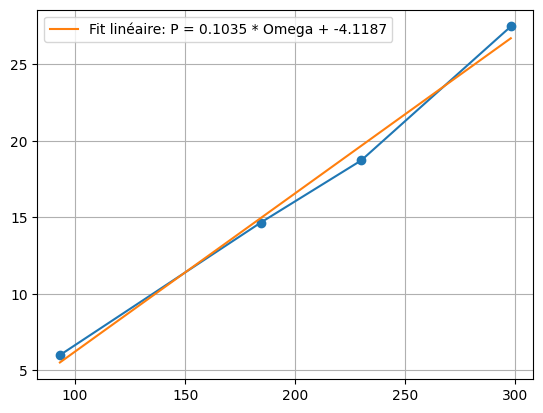

In [623]:
plt.plot(Omega*2*np.pi/60, P_perte_meca, marker='o')
coeffs = np.polyfit(Omega*2*np.pi/60, P_perte_meca, 1)
plt.plot(Omega*2*np.pi/60, np.polyval(coeffs, Omega*2*np.pi/60), label=f'Fit linéaire: P = {coeffs[0]:.4f} * Omega + {coeffs[1]:.4f}')
plt.legend()
plt.grid()

In [624]:
def P_meca_1_mot(Omega):
    return (coeffs[0] * Omega + coeffs[1])/2

In [625]:
T1,I_mes,T2,V_mes = np.loadtxt("10_1mm_12_3V.csv", delimiter=";",skiprows=1, unpack=True)
I1 = I_mes*R_mes_int
V1 = V_mes*1/2 #coeff division par 2

In [626]:
## fonction lissage : retourne un tableau correspondant aux valeurs de signal_brut remplacées par une moyenne glissante, des valeurs qui les entourent, centrée de largeur deux L
def lisser(signal_brut,L):
    res = np.copy(signal_brut) # duplication des valeurs
    for i in range (1,len(signal_brut)-1): # toutes les valeurs sauf la première et la dernière
        L_g = min(i,L) # nombre de valeurs disponibles à gauche
        L_d = min(len(signal_brut)-i-1,L) # nombre de valeurs disponibles à droite
        Li=min(L_g,L_d)
        res[i]=np.sum(signal_brut[i-Li:i+Li+1])/(2*Li+1)
    return res

In [627]:
#n=1000 #13_8mm_17_3V
#n=880 #13_8mm_12_3V
#n=600 #14_4mm_12_3V
#n = 920 #16_8mm_5V Non valable trop bas pour modèle frottement
#n=1177 #11_5mm_12_3V
#n=1050 #9_7mm_12_3V
#n=500 #8_4mm_12_3V
n=600 #10_1mm_12_3V
#n=730 #11_1mm_12_3V
#n=550 #13_3mm_12_3V Ne fonctionne pas, Bizarre
Tension_liss = lisser(V1[:n],40)

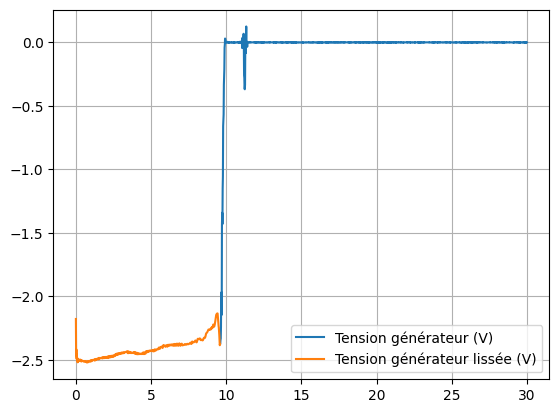

In [628]:
plt.plot(T2[n:],V1[n:], label='Tension générateur (V)')
plt.plot(T2[:n], Tension_liss, label='Tension générateur lissée (V)')
plt.legend()
plt.grid()

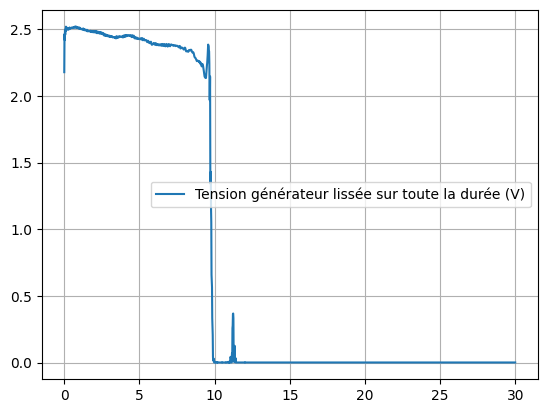

In [629]:
Tension_fin = np.concatenate((np.abs(Tension_liss), np.abs(V1[n:])), axis=0)
plt.plot(T2,Tension_fin, label='Tension générateur lissée sur toute la durée (V)')
plt.grid()
plt.legend()

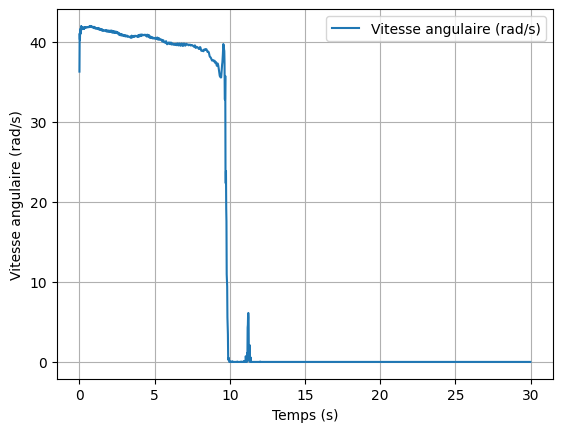

In [630]:
Omega = Tension_fin / phi_0
plt.plot(T2, Omega, label='Vitesse angulaire (rad/s)')
plt.xlabel('Temps (s)')
plt.ylabel('Vitesse angulaire (rad/s)')
plt.grid()
plt.legend()

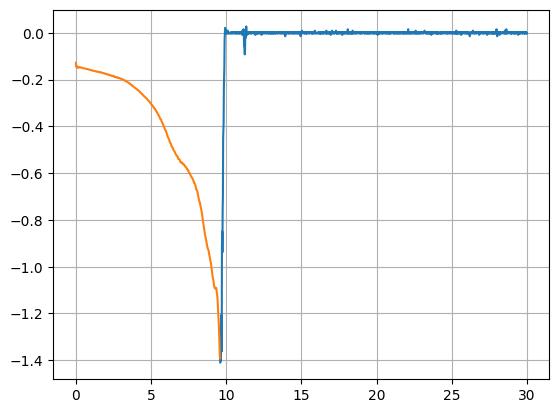

In [631]:
Intensite_liss = lisser(I1[:n],30)
plt.plot(T2[n:],I1[n:], label='Courant générateur (A)')
plt.plot(T2[:n], Intensite_liss, label='Courant générateur lissé (A)')
plt.grid()

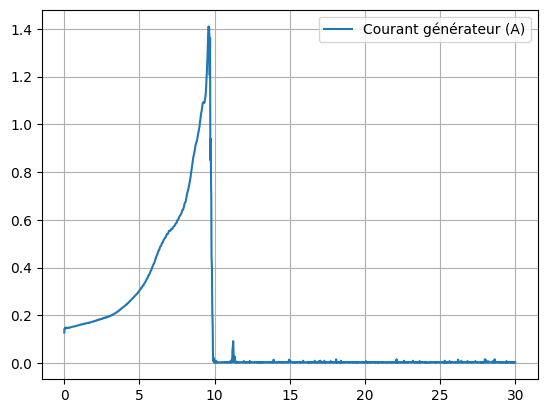

In [632]:
Intensite_fin = np.concatenate((np.abs(Intensite_liss), np.abs(I1[n:])), axis=0)
plt.plot(T2, Intensite_fin, label='Courant générateur (A)')

plt.grid()
plt.legend()


In [633]:
P_perte_meca

array([ 5.995756, 14.657639, 18.722376, 27.4806  ])

array([0.97634612, 1.01072969, 1.03966339, 1.06279457, 1.08454532,
       1.11377961, 1.15204247, 1.19954095, 1.2473637 , 1.26202632])

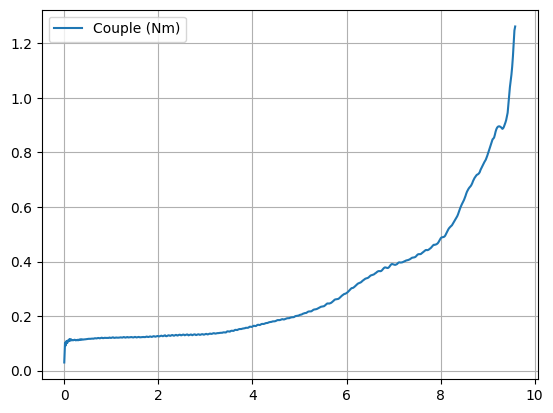

In [634]:
Cpl = ((Tension_fin[:n] * Intensite_fin[:n])+R_gen * Intensite_fin[:n]**2 + P_meca_1_mot(Omega[:n])) / (Omega[:n] * (2 * np.pi / 60))
plt.plot(T2[:n], Cpl, label='Couple (Nm)')

plt.grid()
plt.legend()
Cpl[n-10:n]

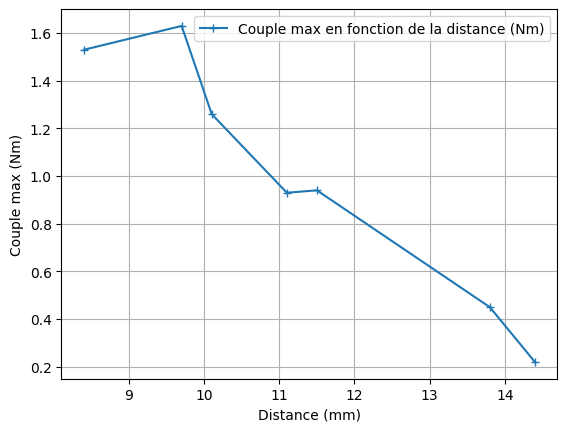

In [635]:
d = [8.4, 9.7, 10.1, 11.1, 11.5,13.8, 14.4] # mm
C_max = [1.53,1.63,1.26,0.93,0.94,0.45,0.22] # Nm
plt.plot(d, C_max, marker='+', label='Couple max en fonction de la distance (Nm)')
plt.xlabel('Distance (mm)')
plt.ylabel('Couple max (Nm)')
plt.grid()
plt.legend()